# 01 · Data Exploration

Explore Spider / BIRD datasets and the synthetic enterprise schemas.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from utils import serialize_schema

## 1. Load synthetic enterprise schemas

In [3]:
schema_path = REPO_ROOT / 'data' / 'synthetic' / 'enterprise_schemas.json'
with open(schema_path) as fh:
    schemas = json.load(fh)

for db_id, schema in schemas.items():
    print(f"\n{'='*60}")
    print(f"DB: {db_id}")
    print(serialize_schema(schema))


DB: tpch
lineitem(l_orderkey, l_partkey, l_suppkey, l_linenumber, l_quantity, l_extendedprice, l_discount, l_tax, l_returnflag, l_linestatus, l_shipdate, l_commitdate, l_receiptdate, l_shipinstruct, l_shipmode, l_comment) | orders(o_orderkey, o_custkey, o_orderstatus, o_totalprice, o_orderdate, o_orderpriority, o_clerk, o_shippriority, o_comment) | customer(c_custkey, c_name, c_address, c_nationkey, c_phone, c_acctbal, c_mktsegment, c_comment) | part(p_partkey, p_name, p_mfgr, p_brand, p_type, p_size, p_container, p_retailprice, p_comment) | supplier(s_suppkey, s_name, s_address, s_nationkey, s_phone, s_acctbal, s_comment) | partsupp(ps_partkey, ps_suppkey, ps_availqty, ps_supplycost, ps_comment) | nation(n_nationkey, n_name, n_regionkey, n_comment) | region(r_regionkey, r_name, r_comment)

DB: enterprise_hr
employee(employee_id, first_name, last_name, email, phone_number, hire_date, job_id, salary, commission_pct, manager_id, department_id) | department(department_id, department_name

## 2. Explore synthetic QA pairs

In [4]:
qa_path = REPO_ROOT / 'data' / 'synthetic' / 'synthetic_qa_pairs.json'
with open(qa_path) as fh:
    qa_pairs = json.load(fh)

df = pd.DataFrame(qa_pairs)
print(f"Total QA pairs: {len(df)}")
print(f"Databases: {df['db_id'].unique().tolist()}")
df.head()

Total QA pairs: 9
Databases: ['tpch', 'enterprise_hr', 'enterprise_sales', 'enterprise_inventory']


,db_id,question,sql
0,tpch,What is the total revenue for orders shipped i...,SELECT SUM(l_extendedprice * (1 - l_discount))...
1,tpch,List the top 5 customers by total order value.,"SELECT c.c_name, SUM(o.o_totalprice) AS total ..."
2,tpch,Find suppliers who supply more than 1000 disti...,"SELECT s.s_name, COUNT(DISTINCT ps.ps_partkey)..."
3,enterprise_hr,Which employees earn more than their manager?,"SELECT e.employee_id, e.first_name, e.last_nam..."
4,enterprise_hr,"Show the average salary per department, sorted...","SELECT d.department_name, AVG(e.salary) AS avg..."


## 3. SQL complexity analysis

       token_count
count     9.000000
mean     42.555556
std       9.875615
min      23.000000
25%      38.000000
50%      40.000000
75%      49.000000
max      56.000000


<Axes: title={'center': 'SQL Feature Frequency'}>

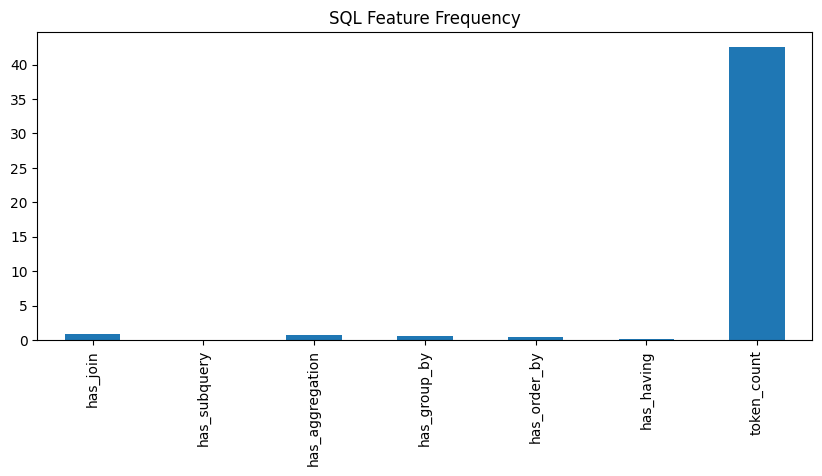

In [5]:
import sqlglot

def sql_complexity(sql: str) -> dict:
    """Simple heuristic complexity metrics."""
    sql_upper = sql.upper()
    return {
        'has_join': 'JOIN' in sql_upper,
        'has_subquery': sql_upper.count('SELECT') > 1,
        'has_aggregation': any(fn in sql_upper for fn in ('SUM(', 'COUNT(', 'AVG(', 'MAX(', 'MIN(')),
        'has_group_by': 'GROUP BY' in sql_upper,
        'has_order_by': 'ORDER BY' in sql_upper,
        'has_having': 'HAVING' in sql_upper,
        'token_count': len(sqlglot.tokenize(sql)),
    }

complexity_df = pd.DataFrame([sql_complexity(row['sql']) for _, row in df.iterrows()])
print(complexity_df.describe())
complexity_df.mean().plot(kind='bar', title='SQL Feature Frequency', figsize=(10, 4))

## 4. Reward function smoke test

In [ ]:
from rewards import format_reward, exec_reward, schema_fidelity_reward

sample_sql = df['sql'].iloc[0]
sample_schema = schemas.get(df['db_id'].iloc[0], {})
completion = [[{'role': 'assistant', 'content': f'```sql\n{sample_sql}\n```'}]]

print('Format reward:', format_reward(completion))
print('Exec reward:', exec_reward(completion, dialect='sqlite'))
print('Schema fidelity reward:', schema_fidelity_reward(completion, schemas=[sample_schema]))

Format reward: [1.0]
Exec reward: [0.0]
Schema fidelity reward: [1.0]
